In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sumo_rl
import random
import pickle
from collections import defaultdict
from sumo_rl.environment.observations import ObservationFunction
from gymnasium import spaces
from pathlib import Path

In [2]:
# Hyperparameters
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.95
learning_rate = 0.1  # Increased for tabular Q-learning (1e-3 is usually too small for tables)
num_seconds = 1000
episodes = 50

In [3]:
def priority_reward_fn(ts):
    """
    Custom reward function that heavily penalizes stopped ambulances and buses.
    ts: The TrafficSignal object provided by sumo_rl.
    """
    reward = 0
    # Access the TraCI connection directly through the traffic signal
    traci = ts.sumo 
    
    # Iterate through all incoming lanes controlled by this specific traffic light
    for lane in ts.lanes:
        # Get the IDs of all vehicles currently on this lane
        vehicles = traci.lane.getLastStepVehicleIDs(lane)
        
        for veh in vehicles:
            # Get the vehicle's current speed
            speed = traci.vehicle.getSpeed(veh)
            
            # If the vehicle is practically stopped (waiting at a red light)
            if speed < 0.1:
                # Retrieve the vehicle type (defined in our .rou.xml file)
                v_type = traci.vehicle.getTypeID(veh)
                
                # Apply custom penalty weights
                if v_type == "ambulance":
                    reward -= 50.0  # Massive penalty for delaying an ambulance
                elif v_type == "bus":
                    reward -= 5.0   # Moderate penalty for delaying a bus
                else:
                    reward -= 1.0   # Standard penalty for normal cars
                    
    return reward

In [4]:
class PriorityObservationFunction(ObservationFunction):
    def __init__(self, ts):
        super().__init__(ts)
        # We need to define the shape of our observation array.
        # Let's say: [density_N, density_S, density_E, density_W, emergency_present_N, emergency_present_S...]
        pass 

    def __call__(self):

        traci = self.ts.sumo
        obs = []
        
        # normal traffic density
        density = self.ts.get_lanes_density()
        obs.extend(density)
        
        # whether an ambulance is waiting on each lane
        for lane in self.ts.lanes:
            emergency_waiting = 0.0
            vehicles = traci.lane.getLastStepVehicleIDs(lane)
            for veh in vehicles:
                if traci.vehicle.getTypeID(veh) == "ambulance":
                    emergency_waiting = 1.0
                    break
            obs.append(emergency_waiting)
            
        return np.array(obs, dtype=np.float32)

    def observation_space(self):
        return spaces.Box(low=0., high=1., shape=(len(self.ts.lanes) * 2,), dtype=np.float32)

In [5]:
def discretize_state(obs):
    """
    Converts continuous density and emergency observations into a discrete, hashable tuple.
    Tabular Q-learning requires discrete states to populate the Q-table.
    """
    half = len(obs) // 2
    discrete_obs = []
    
    # 1. Discretize continuous density (0.0 to 1.0) into 4 distinct bins
    for i in range(half):
        density = obs[i]
        if density < 0.25:
            bin_idx = 0
        elif density < 0.50:
            bin_idx = 1
        elif density < 0.75:
            bin_idx = 2
        else:
            bin_idx = 3
        discrete_obs.append(bin_idx)
        
    # 2. Emergency waiting is already binary (0.0 or 1.0), just cast to int
    for i in range(half, len(obs)):
        discrete_obs.append(int(obs[i]))
        
    return tuple(discrete_obs)

In [8]:
# Initialize PettingZoo environment
base = Path("3x3_priority")
route_files = [
    base / "vtypes.add.xml",
    base / "cars.rou.xml",
    base / "buses.rou.xml",
    base / "bikes.rou.xml",
    base / "ambulance.rou.xml",
]
route = ",".join(str(p) for p in route_files)

env = sumo_rl.parallel_env(
    net_file="./3x3_priority/3x3Grid2lanes.net.xml",
    route_file=route,
    reward_fn=priority_reward_fn,
    observation_class=PriorityObservationFunction,
    use_gui=False, 
    num_seconds=num_seconds,
    delta_time=5,
    sumo_warnings=False
)

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 36ms, vehicles TOT 0 ACT 0 BUF 0)                     


In [9]:
# Get dimensions for the network
sample_agent = env.possible_agents[0]
obs_dim = env.observation_space(sample_agent).shape[0]
action_dim = env.action_space(sample_agent).n

In [10]:
print(obs_dim)
print(action_dim)

16
4


In [11]:
# Initialize Q-Tables for each agent
# Using a nested dictionary (or defaultdict) mapped: q_tables[agent_id][state][action]
q_tables = {}
for agent in env.possible_agents:
    action_dim = env.action_space(agent).n
    # Defaults to all zeros for unseen states
    q_tables[agent] = defaultdict(lambda: np.zeros(action_dim))

In [12]:
all_episode_rewards = []

for episode in range(episodes):
    observations, infos = env.reset()
    episode_reward = 0
    
    # Convert initial observations to discrete states
    states = {agent: discretize_state(observations[agent]) for agent in env.agents}
    
    while env.agents:
        actions = {}
        
        # Action Selection (Epsilon-Greedy)
        for agent in env.agents:
            state = states[agent]
            if random.random() < epsilon:
                # Explore
                actions[agent] = env.action_space(agent).sample()
            else:
                # Exploit (Break ties randomly if all Q-values are 0)
                q_values = q_tables[agent][state]
                max_q = np.max(q_values)
                actions[agent] = random.choice(np.where(q_values == max_q)[0])

        # Step the Environment
        next_observations, rewards, terminations, truncations, infos = env.step(actions)
        
        # Discretize next states
        next_states = {agent: discretize_state(next_observations[agent]) for agent in env.agents}

        # Update Q-Tables
        for agent in env.agents:
            state = states[agent]
            action = actions[agent]
            reward = rewards[agent]
            next_state = next_states[agent]
            done = terminations[agent] or truncations[agent]
            
            # Compute Target Q values
            best_next_action = np.argmax(q_tables[agent][next_state])
            target_q = reward + (gamma * q_tables[agent][next_state][best_next_action] * (1 - done))
            
            # Update Current Q value
            current_q = q_tables[agent][state][action]
            q_tables[agent][state][action] = current_q + learning_rate * (target_q - current_q)
            
            episode_reward += reward

        states = next_states

    all_episode_rewards.append(episode_reward)

    # Decay Epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    print(f"Episode {episode + 1} | Total Shared Reward: {episode_reward:.2f} | Epsilon: {epsilon:.2f}")

env.close()

 Retrying in 1 seconds
Episode 1 | Total Shared Reward: -7648.00 | Epsilon: 0.95
Step #1000.00 (1ms ~= 1000.00*RT, ~100000.00UPS, TraCI: 135ms, vehicles TOT 462 ACT 100 BUF
 Retrying in 1 seconds
Episode 2 | Total Shared Reward: -6204.00 | Epsilon: 0.90
Step #1000.00 (1ms ~= 1000.00*RT, ~87000.00UPS, TraCI: 89ms, vehicles TOT 462 ACT 87 BUF 0)
 Retrying in 1 seconds
Episode 3 | Total Shared Reward: -6517.00 | Epsilon: 0.86
Step #1000.00 (1ms ~= 1000.00*RT, ~93000.00UPS, TraCI: 123ms, vehicles TOT 461 ACT 93 BUF 1
 Retrying in 1 seconds
Episode 4 | Total Shared Reward: -6049.00 | Epsilon: 0.81
Step #1000.00 (1ms ~= 1000.00*RT, ~86000.00UPS, TraCI: 125ms, vehicles TOT 462 ACT 86 BUF 0
 Retrying in 1 seconds
Episode 5 | Total Shared Reward: -7733.00 | Epsilon: 0.77
Step #1000.00 (1ms ~= 1000.00*RT, ~92000.00UPS, TraCI: 126ms, vehicles TOT 461 ACT 92 BUF 1
 Retrying in 1 seconds
Episode 6 | Total Shared Reward: -6105.00 | Epsilon: 0.74
Step #1000.00 (1ms ~= 1000.00*RT, ~77000.00UPS, TraCI:

In [13]:
model_path = "3x3-v3_qtable.pkl"

with open(model_path, "wb") as f:
    # Convert defaultdicts to standard dicts before saving
    serializable_dict = {agent: dict(q_table) for agent, q_table in q_tables.items()}
    pickle.dump(serializable_dict, f)

In [14]:
def plot_rewards(rewards):
    plt.figure(figsize=(10, 5))
    
    plt.plot(rewards, label='Episode Reward', color='dodgerblue', alpha=0.75)
    
    plt.title('Independent DQN Training over 3x3 SUMO Grid')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.savefig('training_curve.png')
    plt.show()

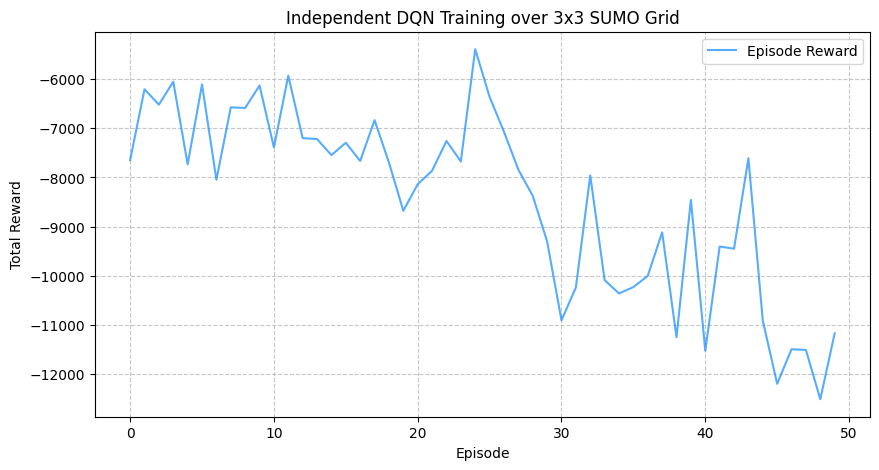

In [15]:
plot_rewards(all_episode_rewards)

In [18]:
env.close()